In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

DATA_URL = "https://raw.githubusercontent.com/OPIM5512-mdk23002/myscrapers-mdk23002/main/data/final_modeling_listings.csv"

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (483, 24)
Columns:
['post_id', 'run_id', 'scraped_at', 'price', 'year', 'make', 'model', 'mileage', 'transmission', 'drivetrain', 'fuel_type', 'engine_cylinders', 'condition', 'color', 'body_type', 'title_status', 'city', 'state', 'zip_code', 'image_url', 'source_txt', 'combined_text', 'combined_text_len', 'has_combined_text']


,post_id,run_id,scraped_at,price,year,make,model,mileage,transmission,drivetrain,...,body_type,title_status,city,state,zip_code,image_url,source_txt,combined_text,combined_text_len,has_combined_text
0,7928977431,20260429110043,2026-04-29T11:00:43Z,3750.0,2005,Jeep,Liberty,99000.0,automatic,4wd,...,suv,clean,Westfield,MA,NaN,NaN,scrapes/20260429110043/7928977431.txt,2005 jeep liberty sport 4x4 for sale by owner ...,1156,True
1,7929999620,20260429110043,2026-04-29T11:00:43Z,7800.0,2011,Honda,CR-V,146000.0,automatic,4wd,...,suv,clean,Fairfield,CT,NaN,NaN,scrapes/20260429110043/7929999620.txt,2011 honda cr-v ex for sale by owner - fairfie...,1059,True
2,7930043364,20260429110043,2026-04-29T11:00:43Z,14200.0,2015,Jeep,Wrangler,37500.0,automatic,4WD,...,suv,clean,New Haven,CT,NaN,NaN,scrapes/20260429110043/7930043364.txt,2015 jeep wrangler unlimited rubicon for sale ...,1039,True
3,7927868905,20260429140043,2026-04-29T14:00:43Z,7900.0,2014,Jeep,Wrangler,163000.0,manual,4wd,...,suv,clean,Shelton,CT,NaN,NaN,scrapes/20260429140043/7927868905.txt,2014 jeep wrangler sport for sale by owner - s...,1716,True
4,7927877622,20260429150247,2026-04-29T15:02:47Z,6985.0,1997,Jaguar,Xk8,61000.0,automatic,rwd,...,convertible,clean,Branford,CT,NaN,NaN,scrapes/20260429150247/7927877622.txt,1997 jaguar xk8 convertible coupe for sale - b...,3129,True


In [20]:
df_model = df.copy()

# Match the structured notebook's target setup:
# use actual_price if available; otherwise use price.
if "actual_price" in df_model.columns:
    df_model["price_num"] = pd.to_numeric(df_model["actual_price"], errors="coerce")
else:
    df_model["price_num"] = pd.to_numeric(df_model["price"], errors="coerce")

# Match the structured notebook's basic price filters.
df_model = df_model.dropna(subset=["price_num"])
df_model = df_model[(df_model["price_num"] > 500) & (df_model["price_num"] < 100000)].copy()

# Create three balanced price tiers.
df_model["price_tier"] = pd.qcut(
    df_model["price_num"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Shape after target cleaning:", df_model.shape)

tier_counts = df_model["price_tier"].value_counts().sort_index()
display(tier_counts)

price_tier_summary = (
    df_model.groupby("price_tier", observed=False)["price_num"]
    .agg(["min", "max", "count"])
)

display(price_tier_summary)

Shape after target cleaning: (465, 26)


,count
price_tier,
low,157
medium,154
high,154


,min,max,count
price_tier,,,
low,1000.0,6500.0,157
medium,6700.0,11900.0,154
high,11998.0,89995.0,154


In [21]:
# ------------------------------------------------------------
# Price leakage check
# ------------------------------------------------------------
# Because combined_text comes from scraped listing text, we should check
# whether the actual asking price appears directly in the text.
# If the exact price appears often, the text model may be learning the target
# too directly instead of learning descriptive price signals.

def price_appears_in_text(row):
    if pd.isna(row["price_num"]):
        return False

    price_int = int(row["price_num"])
    text = str(row["combined_text"]).lower()

    price_variants = [
        str(price_int),
        f"{price_int:,}",
        f"${price_int}",
        f"${price_int:,}"
    ]

    return any(variant.lower() in text for variant in price_variants)

df_model["price_appears_in_text"] = df_model.apply(price_appears_in_text, axis=1)

print("Rows where exact price appears in combined_text:")
print(df_model["price_appears_in_text"].sum())

display(
    df_model.loc[
        df_model["price_appears_in_text"],
        ["price_num", "price_tier", "combined_text"]
    ].head()
)

Rows where exact price appears in combined_text:
9


,price_num,price_tier,combined_text
28,7000.0,medium,"1999 chevy c3500 for sale by owner - trumbull,..."
83,7000.0,medium,"1999 chevy c3500 for sale by owner - trumbull,..."
101,3200.0,low,2011 honda civic cng for sale by owner - water...
151,4900.0,low,"2012 hyundai elantra for sale - branford, ct -..."
229,3900.0,low,"2011 bmw 328ix for sale by owner - new haven, ..."


I checked whether the exact asking price appeared inside 'combined_text'. This is important because the text model should learn descriptive listing signals, not simply memorize the price value from the text. If exact prices appear in only a small number of rows, I will leave the text field as-is and note this as a limitation. If exact prices appear frequently, those values should be removed before vectorization.

In [22]:
def clean_text_value(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"\s+", " ", x)
    return x.strip()

# Prefer the pipeline-created combined_text field.
if "combined_text" in df_model.columns:
    df_model["combined_text"] = df_model["combined_text"].apply(clean_text_value)
else:
    # Fallback only if the final pipeline field is unavailable.
    text_parts = []

    if "title" in df_model.columns:
        text_parts.append(df_model["title"].fillna("").astype(str))
    else:
        text_parts.append(pd.Series([""] * len(df_model), index=df_model.index))

    if "description" in df_model.columns:
        text_parts.append(df_model["description"].fillna("").astype(str))
    else:
        text_parts.append(pd.Series([""] * len(df_model), index=df_model.index))

    df_model["combined_text"] = (text_parts[0] + " " + text_parts[1]).apply(clean_text_value)

print("Rows with non-empty combined_text:", (df_model["combined_text"].str.len() > 0).sum())
print("Total rows:", len(df_model))

# Check whether any combined_text accidentally looks like a path instead of real text.
path_like_text = df_model["combined_text"].str.contains(r"scrapes/|gs://|\.txt", regex=True, na=False)
print("Rows where combined_text looks like a file path:", path_like_text.sum())

display(df_model[["price_num", "price_tier", "combined_text"]].head())

Rows with non-empty combined_text: 465
Total rows: 465
Rows where combined_text looks like a file path: 0


,price_num,price_tier,combined_text
0,3750.0,low,2005 jeep liberty sport 4x4 for sale by owner ...
1,7800.0,medium,2011 honda cr-v ex for sale by owner - fairfie...
2,14200.0,high,2015 jeep wrangler unlimited rubicon for sale ...
3,7900.0,medium,2014 jeep wrangler sport for sale by owner - s...
4,6985.0,medium,1997 jaguar xk8 convertible coupe for sale - b...


In [23]:
if "source_txt" in df_model.columns:
    print(df_model["source_txt"].dropna().astype(str).head(10).tolist())

['scrapes/20260429110043/7928977431.txt', 'scrapes/20260429110043/7929999620.txt', 'scrapes/20260429110043/7930043364.txt', 'scrapes/20260429140043/7927868905.txt', 'scrapes/20260429150247/7927877622.txt', 'scrapes/20260429190051/7927910615.txt', 'scrapes/20260429190051/7929745175.txt', 'scrapes/20260429210038/7927941456.txt', 'scrapes/20260430090025/7930969658.txt', 'scrapes/20260430090025/7930259503.txt']


##Structured Processing for Combined Model

In [24]:
def clean_numeric(series):
    return (
        series
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Numeric fields
if "year" in df_model.columns:
    df_model["year_num"] = clean_numeric(df_model["year"])

if "mileage" in df_model.columns:
    df_model["mileage_num"] = clean_numeric(df_model["mileage"])

if "engine_cylinders" in df_model.columns:
    df_model["engine_cylinders_num"] = clean_numeric(df_model["engine_cylinders"])

if "year_num" in df_model.columns:
    df_model["vehicle_age"] = 2026 - df_model["year_num"]

if "mileage_num" in df_model.columns and "vehicle_age" in df_model.columns:
    df_model["miles_per_year"] = df_model["mileage_num"] / df_model["vehicle_age"].replace(0, np.nan)

candidate_numeric = [
    "year_num",
    "mileage_num",
    "vehicle_age",
    "miles_per_year",
    "engine_cylinders_num"
]

candidate_categorical = [
    "make",
    "model",
    "transmission",
    "drivetrain",
    "fuel_type",
    "condition",
    "color",
    "body_type",
    "title_status"
]

numeric_features = [col for col in candidate_numeric if col in df_model.columns]
categorical_features = [col for col in candidate_categorical if col in df_model.columns]

model_cols = (
    ["post_id", "price_num", "price_tier", "combined_text"]
    + numeric_features
    + categorical_features
)

model_cols = [col for col in model_cols if col in df_model.columns]

df_model_clean = df_model[model_cols].copy()
df_model_clean["combined_text"] = df_model_clean["combined_text"].fillna("").astype(str)

print("Clean modeling shape:", df_model_clean.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

display(df_model_clean.head())

Clean modeling shape: (465, 18)
Numeric features: ['year_num', 'mileage_num', 'vehicle_age', 'miles_per_year', 'engine_cylinders_num']
Categorical features: ['make', 'model', 'transmission', 'drivetrain', 'fuel_type', 'condition', 'color', 'body_type', 'title_status']


,post_id,price_num,price_tier,combined_text,year_num,mileage_num,vehicle_age,miles_per_year,engine_cylinders_num,make,model,transmission,drivetrain,fuel_type,condition,color,body_type,title_status
0,7928977431,3750.0,low,2005 jeep liberty sport 4x4 for sale by owner ...,2005,99000.0,21,4714.285714,6.0,Jeep,Liberty,automatic,4wd,gasoline,NaN,NaN,suv,clean
1,7929999620,7800.0,medium,2011 honda cr-v ex for sale by owner - fairfie...,2011,146000.0,15,9733.333333,4.0,Honda,CR-V,automatic,4wd,gasoline,good,NaN,suv,clean
2,7930043364,14200.0,high,2015 jeep wrangler unlimited rubicon for sale ...,2015,37500.0,11,3409.090909,6.0,Jeep,Wrangler,automatic,4WD,gasoline,like new,NaN,suv,clean
3,7927868905,7900.0,medium,2014 jeep wrangler sport for sale by owner - s...,2014,163000.0,12,13583.333333,6.0,Jeep,Wrangler,manual,4wd,gasoline,good,Silver,suv,clean
4,7927877622,6985.0,medium,1997 jaguar xk8 convertible coupe for sale - b...,1997,61000.0,29,2103.448276,8.0,Jaguar,Xk8,automatic,rwd,gasoline,good,red,convertible,clean


The structured preprocessing is reused from the structured baseline section so the combined model uses the same train/test split, imputation, scaling, one-hot encoding, and label encoding as the baseline model. This keeps the comparison fair and avoids duplicating preprocessing logic.

##Splitting data

In [25]:
train_df, test_df = train_test_split(
    df_model_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_model_clean["price_tier"]
)

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(train_df["price_tier"])
y_test_encoded = label_encoder.transform(test_df["price_tier"])

X_struct_train = train_df[numeric_features + categorical_features]
X_struct_test = test_df[numeric_features + categorical_features]

text_train = train_df["combined_text"]
text_test = test_df["combined_text"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Classes:", label_encoder.classes_)

print("\nTrain class counts:")
display(train_df["price_tier"].value_counts().sort_index())

print("\nTest class counts:")
display(test_df["price_tier"].value_counts().sort_index())

Train size: 372
Test size: 93
Classes: ['high' 'low' 'medium']

Train class counts:


,count
price_tier,
low,126
medium,123
high,123



Test class counts:


,count
price_tier,
low,31
medium,31
high,31


##Preprocessing Structured Features

In [26]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_struct_train)
X_test_processed = preprocessor.transform(X_struct_test)

print("Processed structured train shape:", X_train_processed.shape)
print("Processed structured test shape:", X_test_processed.shape)

Processed structured train shape: (372, 275)
Processed structured test shape: (93, 275)


##Text Vectorization

---



In [27]:
MAX_TOKENS = 5000
MAX_SEQUENCE_LENGTH = 150

text_vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

text_vectorizer.adapt(text_train.values)

vocab = text_vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("Max sequence length:", MAX_SEQUENCE_LENGTH)
print("Example raw text:")
print(text_train.iloc[0][:500])

example_vectorized = text_vectorizer(tf.constant([text_train.iloc[0]]))
print("Example vectorized shape:", example_vectorized.shape)
print("First 30 token IDs:", example_vectorized.numpy()[0][:30])

Vocabulary size: 5000
Max sequence length: 150
Example raw text:
2017 dodge grand caravan for sale - nanuet, ny - craigslist cl new haven > for sale by dealer > cars+trucks post account favorites hidden cl new haven > cars & trucks - by dealer ... ◀ prev ▲ next ▶ reply favorite hide unhide ⚐ ⚑ flag ⚑ flagged posted 2026-05-05 15:31 contact information: print 2017 dodge grand caravan rt - (+ platinum auto mall of rockland) ‹ image 1 of 24 › 61 east route 59 google map  2017 dodge grand caravan vin: 2c4rdgbg6hr765570 drive: fwd fuel: gas odometer: 56,795 paint
Example vectorized shape: (1, 150)
First 30 token IDs: [394 294 431 610   4  15 482 382  23  20  10  16   4  15   6  18 109  11
  82 105  64  20  10  16  39  65   6  18  85  96]


##Text Only LSTM Model

---



In [28]:
num_classes = len(label_encoder.classes_)
EMBEDDING_DIM = 64

model_text_lstm = Sequential([
    Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    Embedding(input_dim=len(vocab), output_dim=EMBEDDING_DIM, mask_zero=True),
    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(num_classes, activation="softmax")
])

model_text_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_text_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 150)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 150, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,203 (1.35 MB)

 Trainable params: 355,203 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

###Model Training

In [29]:
# Using a fresh EarlyStopping callback for each model. Keras callbacks can store
# state during training, so reusing the same callback object across multiple
# models can cause confusing behavior.

def make_early_stop():
    return EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

history_text_lstm = model_text_lstm.fit(
    text_train.values,
    y_train_encoded,
    validation_split=0.20,
    epochs=30,
    batch_size=16,
    callbacks=[make_early_stop()],
    verbose=1
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3973 - loss: 1.0957 - val_accuracy: 0.6400 - val_loss: 1.0874
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6970 - loss: 1.0571 - val_accuracy: 0.5867 - val_loss: 0.9839
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6835 - loss: 0.8353 - val_accuracy: 0.6267 - val_loss: 0.7861
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7980 - loss: 0.5424 - val_accuracy: 0.6533 - val_loss: 0.7463
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9024 - loss: 0.4149 - val_accuracy: 0.6800 - val_loss: 0.7046
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9024 - loss: 0.2808 - val_accuracy: 0.6800 - val_loss: 0.9309
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9125 - loss: 0.2877 - val_accuracy: 0.6933 - val_loss: 0.7863
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9428 - loss: 0.1731 - val_accuracy: 0.7067 - v

###Model Evaluation

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Text-only LSTM Accuracy: 0.6452
Text-only LSTM Weighted F1: 0.6442
              precision    recall  f1-score   support

        high       0.85      0.55      0.67        31
         low       0.61      0.81      0.69        31
      medium       0.56      0.58      0.57        31

    accuracy                           0.65        93
   macro avg       0.67      0.65      0.64        93
weighted avg       0.67      0.65      0.64        93



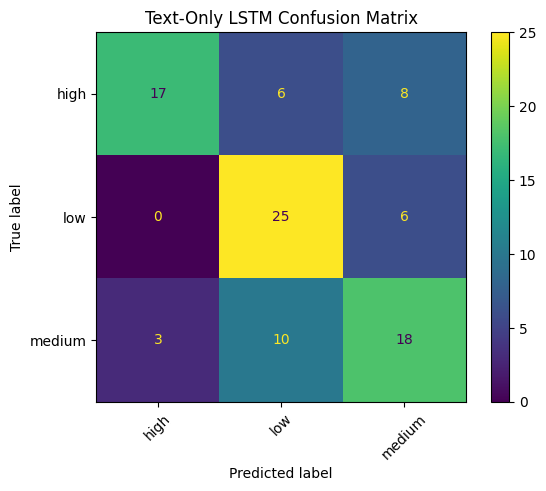

In [30]:
text_probs = model_text_lstm.predict(text_test.values)
text_pred_encoded = np.argmax(text_probs, axis=1)

text_accuracy = accuracy_score(y_test_encoded, text_pred_encoded)
text_weighted_f1 = f1_score(y_test_encoded, text_pred_encoded, average="weighted")

print("Text-only LSTM Accuracy:", round(text_accuracy, 4))
print("Text-only LSTM Weighted F1:", round(text_weighted_f1, 4))

print(classification_report(
    y_test_encoded,
    text_pred_encoded,
    target_names=label_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    text_pred_encoded,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)
plt.title("Text-Only LSTM Confusion Matrix")
plt.show()

##Combined Structured Fields and Text Embedding Model

---



In [31]:
# This uses the Keras Functional API with two branches:
# 1. Structured branch for numeric/categorical vehicle fields
# 2. Text branch for combined_text
#
# The branches are concatenated before the final classification layers.

structured_input = Input(
    shape=(X_train_processed.shape[1],),
    name="structured_input"
)

# Smaller structured branch because the dataset is relatively small.
structured_branch = Dense(32, activation="relu")(structured_input)
structured_branch = Dropout(0.30)(structured_branch)
structured_branch = Dense(16, activation="relu")(structured_branch)

text_input = Input(
    shape=(1,),
    dtype=tf.string,
    name="text_input"
)

text_branch = text_vectorizer(text_input)
text_branch = Embedding(
    input_dim=len(vocab),
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(text_branch)
text_branch = LSTM(32)(text_branch)
text_branch = Dropout(0.30)(text_branch)
text_branch = Dense(16, activation="relu")(text_branch)

merged = Concatenate()([structured_branch, text_branch])
merged = Dense(32, activation="relu")(merged)
merged = Dropout(0.40)(merged)

output = Dense(num_classes, activation="softmax")(merged)

model_combined = Model(
    inputs=[structured_input, text_input],
    outputs=output
)

model_combined.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_combined.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 150)       │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_input    │ (None, 275)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 150, 64)   │    320,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 150)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      8,832 │ structured_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ embedding_3[0][0… │
│                     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        528 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │        528 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32)        │          0 │ dense_11[0][0],   │
│ (Concatenate)       │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │      1,056 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 3)         │         99 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 343,459 (1.31 MB)

 Trainable params: 343,459 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

###Model Training

In [32]:
# Use a new EarlyStopping callback instead of reusing the text-model callback.

history_combined = model_combined.fit(
    {
        "structured_input": X_train_processed,
        "text_input": text_train.values
    },
    y_train_encoded,
    validation_split=0.20,
    epochs=30,
    batch_size=16,
    callbacks=[make_early_stop()],
    verbose=1
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3131 - loss: 1.1048 - val_accuracy: 0.4000 - val_loss: 1.0893
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3973 - loss: 1.0792 - val_accuracy: 0.5333 - val_loss: 1.0722
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4680 - loss: 1.0417 - val_accuracy: 0.6000 - val_loss: 1.0276
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5690 - loss: 0.9429 - val_accuracy: 0.6267 - val_loss: 0.9496
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7306 - loss: 0.7918 - val_accuracy: 0.6933 - val_loss: 0.9461
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7912 - loss: 0.5598 - val_accuracy: 0.6933 - val_loss: 0.9092
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8687 - loss: 0.4012 - val_accuracy: 0.6400 - val_loss: 0.9679
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9293 - loss: 0.2417 - val_accuracy: 0.6267 - v

###Model Evaluation

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Combined Structured + Text Accuracy: 0.7097
Combined Structured + Text Weighted F1: 0.7156
              precision    recall  f1-score   support

        high       0.86      0.61      0.72        31
         low       0.85      0.71      0.77        31
      medium       0.56      0.81      0.66        31

    accuracy                           0.71        93
   macro avg       0.76      0.71      0.72        93
weighted avg       0.76      0.71      0.72        93



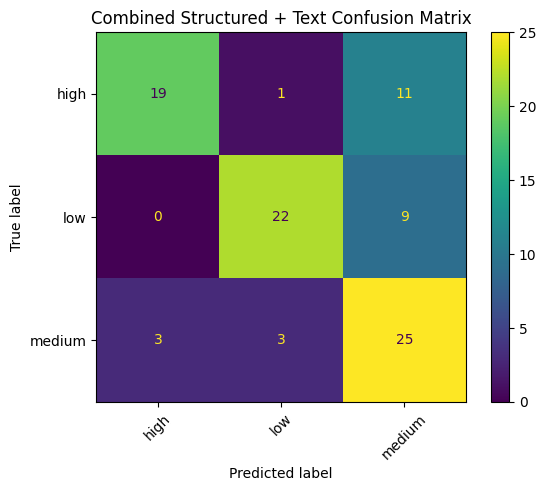

In [33]:
combined_probs = model_combined.predict({
    "structured_input": X_test_processed,
    "text_input": text_test.values
})

combined_pred_encoded = np.argmax(combined_probs, axis=1)

combined_accuracy = accuracy_score(y_test_encoded, combined_pred_encoded)
combined_weighted_f1 = f1_score(y_test_encoded, combined_pred_encoded, average="weighted")

print("Combined Structured + Text Accuracy:", round(combined_accuracy, 4))
print("Combined Structured + Text Weighted F1:", round(combined_weighted_f1, 4))

print(classification_report(
    y_test_encoded,
    combined_pred_encoded,
    target_names=label_encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    combined_pred_encoded,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)
plt.title("Combined Structured + Text Confusion Matrix")
plt.show()

#Training History Plots

---



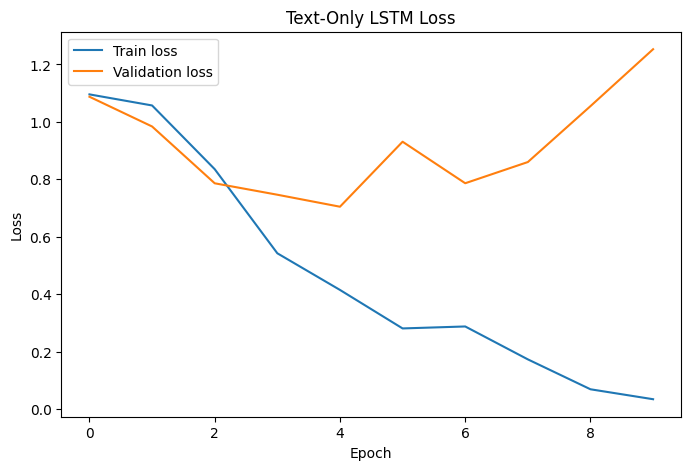

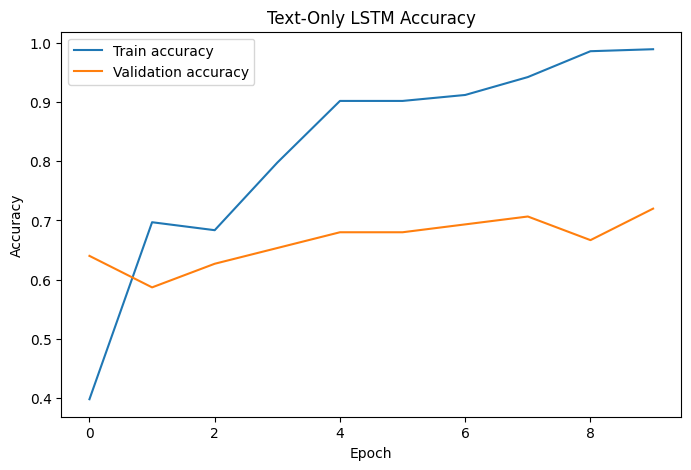

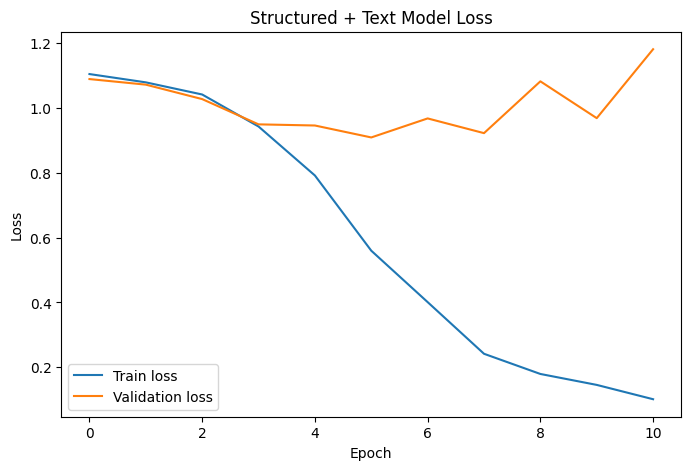

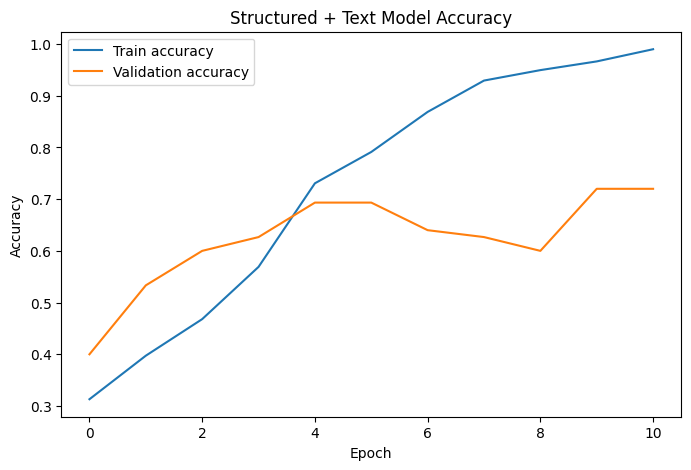

In [34]:
def plot_training_history(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Train loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "accuracy" in history_df.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(history_df["accuracy"], label="Train accuracy")
        plt.plot(history_df["val_accuracy"], label="Validation accuracy")
        plt.title(f"{title} Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

plot_training_history(history_text_lstm, "Text-Only LSTM")
plot_training_history(history_combined, "Structured + Text Model")

#Model Comparison Table

---



In [35]:
model_comparison = pd.DataFrame([
    {
        "model": "Text-only LSTM",
        "inputs": "combined_text",
        "accuracy": text_accuracy,
        "weighted_f1": text_weighted_f1,
        "takeaway": "Tests whether listing language alone predicts price tier."
    },
    {
        "model": "Structured + Text",
        "inputs": "structured fields + combined_text",
        "accuracy": combined_accuracy,
        "weighted_f1": combined_weighted_f1,
        "takeaway": "Tests whether text adds signal when structured fields are also available."
    }
])

display(model_comparison.sort_values("weighted_f1", ascending=False))

,model,inputs,accuracy,weighted_f1,takeaway
1,Structured + Text,structured fields + combined_text,0.709677,0.715602,Tests whether text adds signal when structured...
0,Text-only LSTM,combined_text,0.645161,0.644180,Tests whether listing language alone predicts ...


### Model Comparison Interpretation

The text-only LSTM and structured + text model were evaluated on the same stratified test set, which allows their results to be compared fairly.

The text-only LSTM tests whether listing language alone contains useful signal for classifying vehicles into low, medium, and high price tiers. This model is important because listing text may include signals such as make, model, condition language, seller wording, and vehicle details.

The structured + text model tests whether combining objective vehicle fields with listing text improves performance. If this model does not outperform the text-only model, that is still a useful finding because it shows that added model complexity does not automatically improve performance.

For the final model comparison step, the model with the highest weighted F1 should be treated as the stronger model because weighted F1 reflects performance across all three price tiers while accounting for class support.

#Qualitative Error Analysis

---



In [36]:
# This table shows examples the models got wrong so we can inspect
# what may have confused the model.

def build_error_table(test_df, y_true_encoded, y_pred_encoded, source_model_name, max_rows=10):
    results = test_df.copy()

    # Preserve the car's model name before adding the modeling-method name.
    if "model" in results.columns:
        results = results.rename(columns={"model": "vehicle_model"})

    results["source_model"] = source_model_name
    results["actual_tier"] = label_encoder.inverse_transform(y_true_encoded)
    results["predicted_tier"] = label_encoder.inverse_transform(y_pred_encoded)
    results["correct"] = results["actual_tier"] == results["predicted_tier"]

    results["text_excerpt"] = (
        results["combined_text"]
        .fillna("")
        .astype(str)
        .str.slice(0, 250)
    )

    display_cols = [
        "source_model",
        "post_id",
        "price_num",
        "actual_tier",
        "predicted_tier",
        "correct"
    ]

    for col in ["year_num", "mileage_num", "make", "vehicle_model", "condition", "body_type"]:
        if col in results.columns:
            display_cols.append(col)

    display_cols.append("text_excerpt")

    errors = results[results["correct"] == False][display_cols]

    print(f"{source_model_name} incorrect predictions:", len(errors))
    return errors.head(max_rows)

text_errors = build_error_table(
    test_df,
    y_test_encoded,
    text_pred_encoded,
    "Text-only LSTM"
)

combined_errors = build_error_table(
    test_df,
    y_test_encoded,
    combined_pred_encoded,
    "Structured + Text"
)

display(text_errors)
display(combined_errors)

Text-only LSTM incorrect predictions: 33
Structured + Text incorrect predictions: 27


,source_model,post_id,price_num,actual_tier,predicted_tier,correct,year_num,mileage_num,make,vehicle_model,condition,body_type,text_excerpt
5,Text-only LSTM,7927910615,22500.0,high,medium,False,2020,97000.0,Jeep,Grand Cherokee,like new,suv,2020 jeep grand cherokee for sale by owner - w...
482,Text-only LSTM,7932760061,7600.0,medium,low,False,2010,146000.0,Honda,Cr-v,like new,suv,2010 honda cr-v lx for sale by owner - fairfie...
383,Text-only LSTM,7932485853,5900.0,low,medium,False,2014,123296.0,Kia,Soul,NaN,wagon,"2014 kia soul gl for sale - branford, ct - cra..."
293,Text-only LSTM,7931381712,8999.0,medium,low,False,2013,112885.0,Honda,Civic,like new,sedan,"2013 honda civic for sale - hooksett, nh - cra..."
309,Text-only LSTM,7930047015,13900.0,high,medium,False,1997,130000.0,Chevrolet,Camaro,good,coupe,1997 chevy camaro z28 for sale by owner - new ...
292,Text-only LSTM,7931422606,22500.0,high,medium,False,2015,30414.0,Ford,F250,like new,truck,2015 ford f250 super duty for sale - west have...
372,Text-only LSTM,7931384137,32700.0,high,low,False,2016,92000.0,Ford,Transit,good,van,2016 ford transit 350 xl wheelchair van for sa...
70,Text-only LSTM,7928537369,8500.0,medium,low,False,2016,98804.0,Chevrolet,Suburban,like new,suv,2016 chevrolet suburban lt for sale by owner -...
58,Text-only LSTM,7928523469,9900.0,medium,high,False,2013,148609.0,Mercedes-Benz,E350,like new,wagon,2013 mercedes benz e350 4matic wagon for sale ...
392,Text-only LSTM,7930618675,10750.0,medium,low,False,2011,42984.0,Mazda,Miata,good,convertible,2011 mazda mx-5 miata for sale by owner - shel...


,source_model,post_id,price_num,actual_tier,predicted_tier,correct,year_num,mileage_num,make,vehicle_model,condition,body_type,text_excerpt
190,Structured + Text,7931481836,47500.0,high,medium,False,1962,87572.0,Chevrolet,Bel Air,NaN,NaN,"1962 chevrolet bel air for sale - bridgeport, ..."
328,Structured + Text,7929995522,3000.0,low,medium,False,2007,177000.0,BMW,328i,good,sedan,"2007 bmw 328i for sale by owner - new haven, c..."
293,Structured + Text,7931381712,8999.0,medium,low,False,2013,112885.0,Honda,Civic,like new,sedan,"2013 honda civic for sale - hooksett, nh - cra..."
58,Structured + Text,7928523469,9900.0,medium,high,False,2013,148609.0,Mercedes-Benz,E350,like new,wagon,2013 mercedes benz e350 4matic wagon for sale ...
336,Structured + Text,7930047083,3700.0,low,medium,False,2013,220000.0,Hyundai,Sonata,good,sedan,2013 hyundai sonata for sale by owner - new ha...
238,Structured + Text,7930184850,3900.0,low,medium,False,2000,197000.0,Ford,Mustang,good,convertible,2000 ford mustang convertible for sale - branf...
388,Structured + Text,7932557599,13500.0,high,low,False,2016,142000.0,Chevrolet,Silverado,good,truck,2016 chevy silverado 1500 for sale by owner - ...
303,Structured + Text,7929970578,8100.0,medium,low,False,2017,114000.0,BMW,320i,like new,sedan,2017 bmw 320i xdrive for sale by owner - green...
72,Structured + Text,7928723431,7295.0,medium,low,False,2009,143686.0,Honda,Civic,good,coupe,2009 honda civic ex-l for sale - north branfor...
475,Structured + Text,7932589568,6250.0,low,medium,False,2009,167283.0,Honda,Accord,NaN,sedan,"2009 honda accord for sale - bridgeport, ct - ..."
